## Actividad de clase

1. obtén la clasificación total de los datos. 

2. crea un nuevo modelo con Depth de 1 y otro con Depth de none, visualiza los resultados y comenta que es lo que sucede en cada uno. que notas en los cuadros de hasta abajo cuando no hay limite?. 

3. aplica una matriz de correlación para ver si todos los datos son realmente importantes en el dataset, si no es así limpia ese data set seleccionando los datos con mayor relación. 

### Actividad 1

sepal length (cm)    150
sepal width (cm)     150
petal length (cm)    150
petal width (cm)     150
especie              150
dtype: int64
Primeras 5 filas de nuestros datos:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


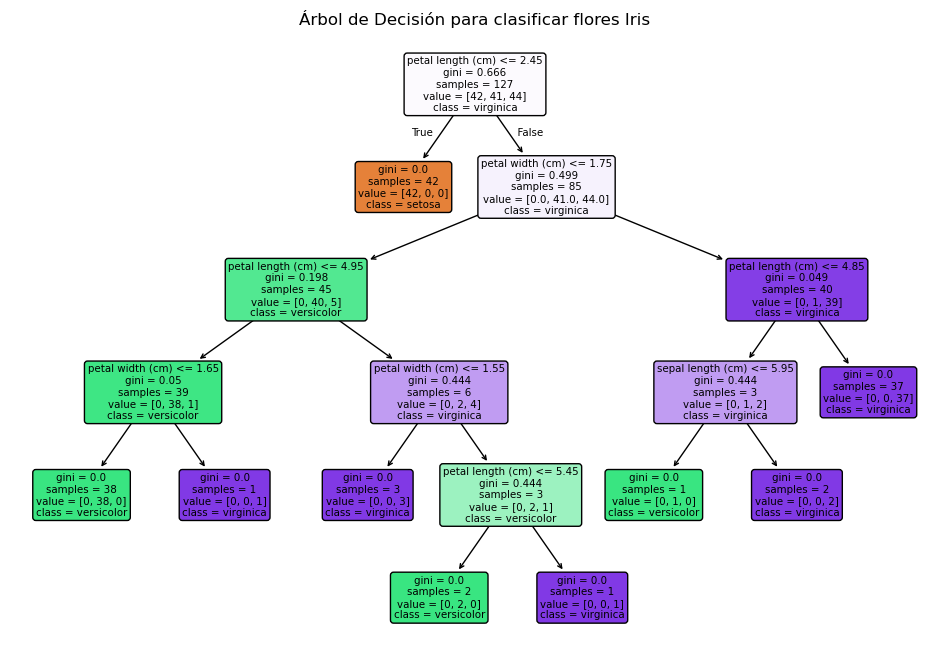

In [2]:
# Importamos las librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Cargamos el dataset Iris
iris = load_iris()
X = iris.data # Las características (medidas de las flores)
y = iris.target # Las etiquetas (el tipo de flor real)

feature_names = iris.feature_names


# Lo convertimos a una tabla (DataFrame) para verlo mejor
df = pd.DataFrame(X, columns=feature_names)
df['especie'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(df.count())
print("Primeras 5 filas de nuestros datos:")
display(df.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
 
arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol.fit(X_train, y_train)
 
plt.figure(figsize=(12,8))
plot_tree(arbol, feature_names=feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Árbol de Decisión para clasificar flores Iris")
plt.show()

### Actividad 2: Modelo con depth de 1 y None

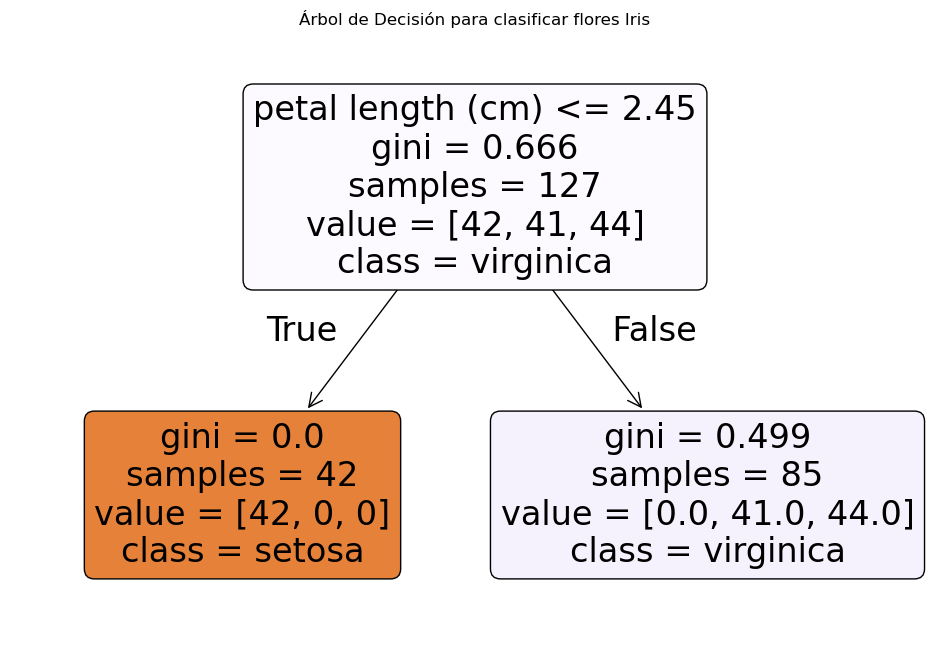

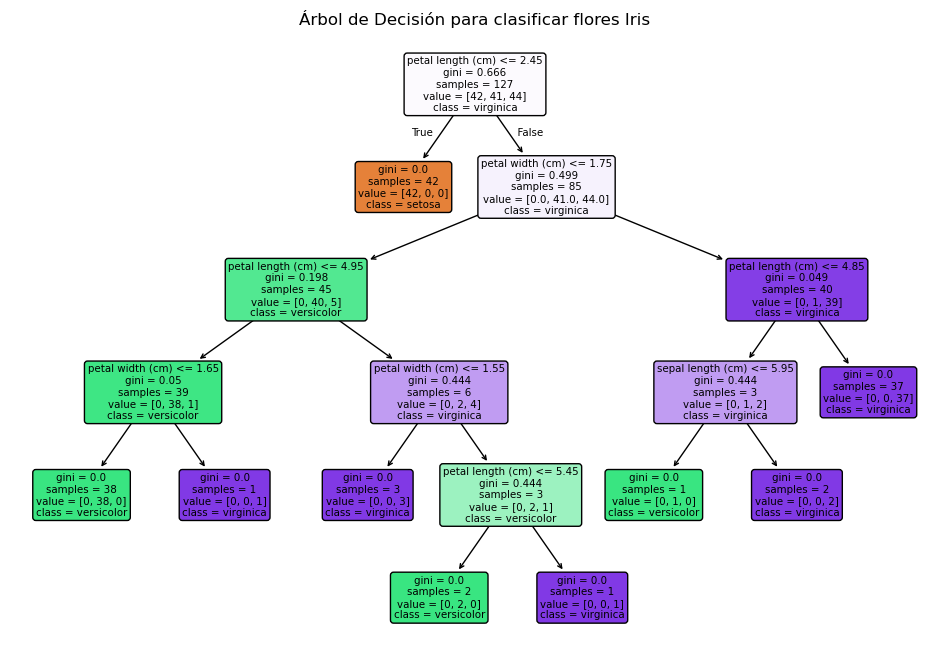

In [22]:
# Arbol deed de 0
arbol = DecisionTreeClassifier(max_depth=1, random_state=42)
arbol.fit(X_train, y_train)
plt.figure(figsize=(12,8))
plot_tree(arbol, feature_names=feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Árbol de Decisión para clasificar flores Iris")
plt.show()


# Arbol deed de 0
arbol = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol.fit(X_train, y_train)
plt.figure(figsize=(12,8))
plot_tree(arbol, feature_names=feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Árbol de Decisión para clasificar flores Iris")
plt.show()

Si no se define un limite especifico, el algoritmo puede continuar generando rama sin limite, dentro de este ejemplo, los niveles máximos que se generarón son 5, ain embargo, se podría dar el caso donde tngamos n ramas donde el procesamiento se vuelva exponencial.

### Actividad 3

Head del dataframe


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Matriz de correlación entre las características:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


,sepal length (cm),petal length (cm),petal width (cm)
0,5.1,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,0.2
4,5.0,1.4,0.2


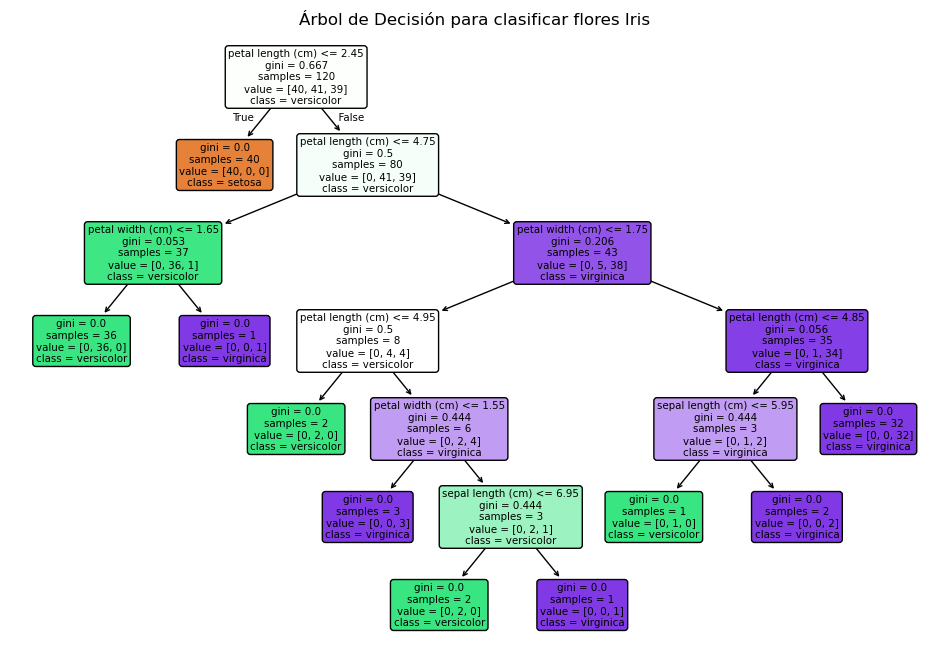

In [46]:
# Importamos las librerías fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Cargamos el dataset Iris
iris = load_iris()
X = iris.data # Las características (medidas de las flores)
y = iris.target # Las etiquetas (el tipo de flor real)

feature_names = iris.feature_names

# Lo convertimos a una tabla (DataFrame) para verlo mejor
df = pd.DataFrame(X, columns=tuple(feature_names))

print('Head del dataframe')
display(df.head())

print("Matriz de correlación entre las características:")
display(df.corr('pearson'))

df['especie'] = pd.Categorical.from_codes(iris.target, iris.target_names)

temp_list = list(feature_names)
temp_list.remove('sepal width (cm)')
display(df[temp_list].head())

X_train, X_test, y_train, y_test = train_test_split(
                                                    df[temp_list].values, 
                                                    df['especie'].values, 
                                                    test_size=0.2, 
                                                    random_state=42)
 
arbol = DecisionTreeClassifier(max_depth=None, random_state=42)
arbol.fit(X_train, y_train)
 
plt.figure(figsize=(12,8))
plot_tree(arbol, feature_names=temp_list, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Árbol de Decisión para clasificar flores Iris")
plt.show()
